# 1 Import

In [1]:
#  UNITÉS (définitives, validées sur les données brutes) :
#  ─────────────────────────────────────────────────────
#  yield              : % (ex: 1.396 pour 1.396%)
#  price              : price points base 100 (ex: 104.835)
#  dv01 source        : pour notional=1  (ex: 0.000907 pour Bund 10 ans)
#  dv01 réel          : pour notional=100 = dv01_source × 100 (ex: 0.0907)
#  dy_bp              : bp  (= diff(yield) × 100, car yield en %)
#  pnl_carry          : décimal de notional  (Δaccrued/100 + coupons/100)
#  pnl_yield          : décimal de notional  (= -dv01_source × dy_bp)
#  pnl_total_unit     : décimal de notional  (= pnl_yield + pnl_carry)
#  carry_bp_equiv     : bp  (= pnl_carry / dv01_source)
#  ret_total_per_dv01 : bp  (= -dy_bp + carry_bp_equiv)
#  bid_offer_yield    : bp  (= q25_spread_yield × 100)
#
#  VÉRIFICATION COHÉRENCE :
#    pnl_total_unit ≈ ret_total_per_dv01 × dv01_source
#    ex: -2 bp × 0.000907 = -0.00181 décimal ✅
#    carry annualisé : carry_bp_equiv × 252 ≈ 10-50 bp/an ✅
# =============================================================================

import numpy as np
import pandas as pd
import warnings
import re
from functools import lru_cache

import QuantLib as ql

warnings.filterwarnings("ignore")

# =============================================================================
#  0. CONSTANTES
# =============================================================================

COUNTRIES_UNIVERSE = ["FR", "DE", "IT"]

COUNTRY_DEFAULT_FREQ_MAP = {
    "FR": 1, "DE": 1, "IT": 2, 
}

# DV01 de référence FIXE pour normalisation portefeuille
# = dv01_source × 100 d'un bond 10 ans ≈ 0.000907 × 100 = 0.0907
DV01_REF = 0.09   # notional 100

# Clip des sauts de benchmark (changement d'ISIN de référence dans un bucket)
CLIP_RET_BP = 20  # bp

# Bid/offer multiplicateurs pour composés
BID_OFFER_MULTIPLIER = {
    "spread": 0.5,
    "curve":  0.4,
    "fly":    0.25,
    "box":    0.375,
}

# Filtre qualité ISINs
MIN_OBS_PER_ISIN = 20
MAX_DAILY_CARRY  = 0.005   # 0.5% de notional par jour = aberrant


# =============================================================================
#  1. CALENDRIERS QUANTLIB
# =============================================================================



# 2 Pipeline des données

## 2.1 Carry par ISIN (QuantLib)

In [2]:
# =============================================================================
#  1. CARRY PAR ISIN (QuantLib)
# =============================================================================
def get_calendar(country_iso: str) -> ql.Calendar:
    return {
        "FR": ql.France(),
        "DE": ql.Germany(),
        "IT": ql.Italy(),
        "SP": ql.Spain(),
        "PT": ql.Portugal(),
        "BE": ql.Belgium(),
        "AT": ql.Austria(),
        "NL": ql.Netherlands(),
    }.get(country_iso, ql.TARGET())

@lru_cache(maxsize=None)
def _build_bond(issue_date, maturity_date, coupon_pct, freq, country_iso):
    """
    Construit un FixedRateBond QuantLib.
    coupon_pct : en % (ex: 1.5 pour 1.5%) — tel que dans metadata_bonds.csv
    Retourne (bond, [(ql.Date, amount), ...])
    """
    cal      = get_calendar(country_iso)
    daycount = ql.ActualActual(ql.ActualActual.ISMA)
    freq_map = {1: ql.Annual, 2: ql.Semiannual, 4: ql.Quarterly}
    frequency = freq_map.get(int(freq), ql.Semiannual)

    issue_ql = ql.Date(issue_date.day, issue_date.month, issue_date.year)
    mat_ql   = ql.Date(maturity_date.day, maturity_date.month, maturity_date.year)

    schedule = ql.Schedule(
        issue_ql, mat_ql,
        ql.Period(frequency), cal,
        ql.Following, ql.Following,
        ql.DateGeneration.Backward, False,
    )

    # QuantLib attend un taux décimal : coupon_pct / 100
    bond = ql.FixedRateBond(0, 100.0, schedule, [float(coupon_pct) / 100.0], daycount)
    cfs  = sorted(
        [(cf.date(), float(cf.amount()))
         for cf in bond.cashflows() if isinstance(cf, ql.Coupon)],
        key=lambda x: x[0]
    )
    return bond, cfs


def _compute_carry_for_isin(df_isin: pd.DataFrame) -> pd.DataFrame:
    """
    pnl_carry journalier en décimal de notional :
      = (Δaccrued + coupons payés dans (t-1, t]) / 100

    Fallback si métadonnées manquantes :
      ≈ (price/100) × (yield/100) / 252
    """
    df = df_isin.copy()
    df = df.sort_values("time_stamp")

    needs = ["issue_date", "maturity_date", "coupon", "cpn_freq", "country_iso"]
    if any(c not in df.columns or df[c].isna().all() for c in needs):
        df["pnl_carry"] = (df["price"] / 100.0) * (df["yield"] / 100.0) / 252.0
        return df  # isin toujours présent ✅

    issue_date    = df["issue_date"].iloc[0]
    maturity_date = df["maturity_date"].iloc[0]
    coupon_pct    = float(df["coupon"].iloc[0])   # en %, ex: 1.5
    freq          = int(df["cpn_freq"].iloc[0])
    country_iso   = df["country_iso"].iloc[0]

    try:
        bond, cfs = _build_bond(issue_date, maturity_date, coupon_pct, freq, country_iso)
    except Exception as e:
        warnings.warn(f"QuantLib error: {e}")
        df["pnl_carry"] = (df["price"] / 100.0) * (df["yield"] / 100.0) / 252.0
        return df

    cf_dates     = [d for d, _ in cfs]
    cf_amts      = [a for _, a in cfs]
    carry        = np.zeros(len(df), dtype=float)
    prev_ql      = None
    accrued_prev = None
    k            = 0

    for i, ts in enumerate(df["time_stamp"].tolist()):
        d       = ql.Date(ts.day, ts.month, ts.year)
        accrued = float(bond.accruedAmount(d))   # price points sur base 100

        if prev_ql is None:
            carry[i] = 0.0
            while k < len(cf_dates) and cf_dates[k] <= d:
                k += 1
        else:
            coupons = 0.0
            while k < len(cf_dates) and cf_dates[k] <= d:
                coupons += cf_amts[k]
                k += 1
            # price points → décimal de notional
            carry[i] = ((accrued - accrued_prev) + coupons) / 100.0

        prev_ql      = d
        accrued_prev = accrued

    df["pnl_carry"] = carry
    return df

## 2.2 Chargement et nettoyage

In [3]:
# =============================================================================
#  2. CHARGEMENT & NETTOYAGE
# =============================================================================

def load_and_clean_raw(
    path_mids: str = "data/benchmark_mids_cs.csv",
    path_meta: str = "data/metadata_bonds.csv",
) -> pd.DataFrame:

    print("  Chargement benchmark_mids_cs...")
    data = pd.read_csv(path_mids)

    # Timestamp avec timezone → date pure
    data["time_stamp"] = pd.to_datetime(data["time_stamp"], utc=True).dt.tz_localize(None)

    # Filtrer sur l'univers
    data = data[data["country_iso"].isin(COUNTRIES_UNIVERSE)].copy()

    # Dédoublonnage : dernière observation par jour par ISIN
    data = (
        data
        .groupby(["isin", data["time_stamp"].dt.date], as_index=False)
        .last()
    )
    data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
    data = data.sort_values(["isin", "time_stamp"]).reset_index(drop=True)

    # mat_cat en string pour noms de produits
    data["mat_cat"] = data["mat_cat"].astype(str)

    # Supprimer lignes sans prix/yield/dv01
    data = data.dropna(subset=["price", "yield", "dv01"])

    # Métadonnées
    print("  Chargement metadata_bonds...")
    meta = pd.read_csv(path_meta)
    meta["issue_date"]    = pd.to_datetime(meta["issue_date"],    errors="coerce")
    meta["maturity_date"] = pd.to_datetime(meta["maturity_date"], errors="coerce")
    meta["coupon"]        = pd.to_numeric(meta["coupon"],         errors="coerce")  # en %
    meta["cpn_freq"]      = pd.to_numeric(meta["cpn_freq"],       errors="coerce")
    meta = meta[["isin","issue_date","maturity_date","coupon","cpn_freq"]].drop_duplicates("isin")

    data = data.merge(meta, on="isin", how="left")

    # Fréquence coupon par défaut
    data["cpn_freq"] = (
        data["cpn_freq"]
        .fillna(data["country_iso"].map(COUNTRY_DEFAULT_FREQ_MAP))
        .fillna(2)
        .astype(int)
    )

    print(f"  Après nettoyage : {data['isin'].nunique()} ISINs, "
          f"{data['time_stamp'].nunique()} dates, {len(data):,} lignes")
    return data

## 2.3 Calcul returns

In [4]:
# =============================================================================
#  4. CALCUL DES RETURNS
# =============================================================================

def compute_returns(data: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute :
      dy_bp              : diff(yield) × 100  [bp]
      pnl_carry          : QuantLib            [décimal]
      pnl_yield          : -dv01_source × dy_bp [décimal]
      pnl_total_unit     : pnl_yield + pnl_carry [décimal]
      carry_bp_equiv     : pnl_carry / dv01_source [bp]
      ret_total_per_dv01 : -dy_bp + carry_bp_equiv [bp]
    """
    # dy_bp : yield en % → diff en % → ×100 pour bp
    data["dy_bp"] = data.groupby("isin")["yield"].diff() * 100

    print("  Calcul carry QuantLib...")
    # Sauvegarde du mapping index → isin AVANT l'apply
    isin_map = data["isin"].copy()

    data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)

    # Réassignation de isin si elle a été droppée
    if "isin" not in data.columns:
        data["isin"] = isin_map.reindex(data.index)

    # Filtre qualité ISINs
    valid = (
        data.groupby("isin")
        .filter(lambda x:
            len(x) >= MIN_OBS_PER_ISIN
            and x["pnl_carry"].abs().max() < MAX_DAILY_CARRY
        )["isin"].unique()
    )
    n_before = data["isin"].nunique()
    data = data[data["isin"].isin(valid)]
    print(f"  Filtre qualité : {n_before - data['isin'].nunique()} ISINs retirés")

    # pnl_yield = -dv01_source × dy_bp  [décimal]
    # cohérence : 0.000907 × 2 bp = 0.00181 décimal ✅
    data["pnl_yield"]      = -data["dv01"] * data["dy_bp"]
    data["pnl_total_unit"] =  data["pnl_yield"] + data["pnl_carry"]

    # carry_bp_equiv = pnl_carry / dv01_source  [bp]
    # cohérence : 0.0000595 / 0.000907 = 0.066 bp/jour × 252 = 16 bp/an ✅
    eps = data["dv01"].quantile(0.01)
    data["carry_bp_equiv"] = np.where(
        np.abs(data["dv01"]) > eps,
        data["pnl_carry"] / data["dv01"],
        0.0,
    )

    # ret_total_per_dv01 = -dy_bp + carry_bp_equiv  [bp]
    data["ret_total_per_dv01"] = -data["dy_bp"] + data["carry_bp_equiv"]

    # Sanity checks
    med_dy    = data["dy_bp"].abs().median()
    med_carry = data["carry_bp_equiv"].abs().median()
    med_ret   = data["ret_total_per_dv01"].abs().median()
    print(f"  dy_bp              médiane abs : {med_dy:.4f} bp/jour  (attendu 0.5–5)")
    print(f"  carry_bp_equiv     médiane abs : {med_carry:.6f} bp/jour  (attendu 0.01–0.2)")
    print(f"  ret_total_per_dv01 médiane abs : {med_ret:.4f} bp/jour  (attendu 0.5–5)")

    # Vérification cohérence pnl vs ret×dv01
    check = (data["pnl_total_unit"] / (data["ret_total_per_dv01"] * data["dv01"])).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    print(f"  Ratio pnl / (ret×dv01) médian : {check.median():.3f}  (attendu ~1.0)")

    return data

## 2.4 Format produit

In [5]:
# =============================================================================
#  5. FORMAT PRODUIT
# =============================================================================

def build_data_completed(data: pd.DataFrame) -> pd.DataFrame:
    """
    ISIN → produit (country_iso_mat_cat), médiane par bucket.
    """
    data = data.copy()
    data["product"] = data["country_iso"] + "_" + data["mat_cat"]
 
    agg_dict = {
        "ret_total_per_dv01": ("ret_total_per_dv01", "median"),
        "pnl_total_unit":     ("pnl_total_unit",     "median"),
        "dv01":               ("dv01",               "median"),
        "carry_bp_equiv":     ("carry_bp_equiv",     "median"),
        "maturity_date":      ("maturity_date",      "min"),
    }
 
    # issue_date : max = émission la plus récente = bond on-the-run
    if "issue_date" in data.columns:
        agg_dict["issue_date"] = ("issue_date", "max")
 
    data_completed = (
        data
        .groupby(["time_stamp", "product"])
        .agg(**agg_dict)
        .reset_index()
    )
 
    data_completed["time_stamp"]    = pd.to_datetime(data_completed["time_stamp"])
    data_completed["maturity_date"] = pd.to_datetime(data_completed["maturity_date"])
    if "issue_date" in data_completed.columns:
        data_completed["issue_date"] = pd.to_datetime(data_completed["issue_date"])
 
    # Clip sauts de benchmark
    n_clip = (data_completed["ret_total_per_dv01"].abs() > CLIP_RET_BP).sum()
    if n_clip > 0:
        print(f"  Clip sauts ISIN : {n_clip} valeurs |ret| > {CLIP_RET_BP} bp")
    data_completed["ret_total_per_dv01"] = (
        data_completed["ret_total_per_dv01"].clip(-CLIP_RET_BP, CLIP_RET_BP)
    )
 
    print(f"  data_completed : {data_completed['product'].nunique()} produits, "
          f"{data_completed['time_stamp'].nunique()} dates, "
          f"{len(data_completed):,} lignes")
    return data_completed

## 2.5 Bid/offer 

In [6]:
# =============================================================================
#  6. BID/OFFER
# =============================================================================

def load_bidoffer(path_bo: str = "data/bid_offer_CS.csv") -> pd.Series:
    """
    bid/offer en bp pour les bonds simples de l'univers FR/DE/IT.
    q25_spread_yield est en décimal → ×100 pour bp.
    """
    bo = pd.read_csv(path_bo)
    bo["mat_cat"] = bo["mat_cat"].astype(str)
    bo = bo[bo["country_iso"].isin(COUNTRIES_UNIVERSE)].copy()
    bo["product"] = bo["country_iso"] + "_" + bo["mat_cat"]

    bond_bidoffer = (
        bo.groupby("product")["q25_spread_yield"]
        .median()
        .rename("bid_offer_yield")
        * 100   # décimal → bp
    )

    print(f"  bid_offer (bp) :\n{bond_bidoffer.sort_index().to_string()}")
    return bond_bidoffer

## 2.6 Spread Curve 

In [7]:
def add_spread_curve(
    data: pd.DataFrame,
    value_col: str      = "pnl_total_unit",
    bond_bidoffer_yield = None,
    bid_offer_multiplier= None,
) -> pd.DataFrame:
    """
    Construit bonds + spreads pays + spreads courbe + flies + slopes.
    Propage bid_offer_yield [bp], maturity_date, issue_date, carry_bp_equiv
    de façon time-varying (panel dates×produits).

    Fix carry NaN : ffill sur les jambes AVANT construction des composés,
    puis ffill sur les composés AVANT le melt final.
    """
    if bid_offer_multiplier is None:
        bid_offer_multiplier = BID_OFFER_MULTIPLIER

    df        = data.copy()
    products  = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:    return sorted(mats, key=lambda x: float(x))
        except: return sorted(mats)

    maturities   = sort_mats({p.split("_")[1] for p in products})
    product_type = {p: "bond" for p in products}
    bidoffer_product = {}

    wide = df.pivot(index="time_stamp", columns="product", values=value_col).sort_index()

    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = float(bond_bidoffer_yield.loc[p])

    # ── maturity_date time-varying ────────────────────────────────────────────
    HAS_MAT = "maturity_date" in df.columns
    if HAS_MAT:
        mat_wide = df.pivot_table(
            index="time_stamp", columns="product",
            values="maturity_date", aggfunc="min"
        ).reindex(wide.index)
    else:
        mat_wide = pd.DataFrame(index=wide.index)

    # ── issue_date time-varying ───────────────────────────────────────────────
    HAS_ISSUE = "issue_date" in df.columns
    if HAS_ISSUE:
        issue_wide = df.pivot_table(
            index="time_stamp", columns="product",
            values="issue_date", aggfunc="max"
        ).reindex(wide.index)
    else:
        issue_wide = pd.DataFrame(index=wide.index)

    # ── carry_bp_equiv time-varying ───────────────────────────────────────────
    HAS_CARRY = "carry_bp_equiv" in df.columns
    if HAS_CARRY:
        carry_wide = df.pivot_table(
            index="time_stamp", columns="product",
            values="carry_bp_equiv", aggfunc="mean"
        ).reindex(wide.index)

        # FIX : interpoler les trous sur chaque jambe (bond simple) AVANT
        # de construire les composés → évite la propagation de NaN
        carry_wide = carry_wide.ffill().bfill()
    else:
        carry_wide = pd.DataFrame(index=wide.index)

    carry_legs_wide = carry_wide.copy() if HAS_CARRY else pd.DataFrame(index=wide.index)

    # ── helpers ───────────────────────────────────────────────────────────────

    def _carry_series(legs):
        """Carry time-varying pour un composé = Σ coef * carry_leg(t)."""
        if not HAS_CARRY:
            return pd.Series(np.nan, index=wide.index)
        total = pd.Series(0.0, index=wide.index)
        for p, coef in legs:
            if p not in carry_legs_wide.columns:
                return pd.Series(np.nan, index=wide.index)
            total = total + coef * carry_legs_wide[p]
        return total

    def _bo_composite(legs, mult_key):
        bos = [bidoffer_product.get(p, np.nan) for p, _ in legs]
        if not all(np.isfinite(b) for b in bos): return np.nan
        return np.mean(bos) * bid_offer_multiplier[mult_key]

    def _add(name, series, ptype, legs, bo_key):
        if name in wide.columns: return
        wide[name]         = series
        product_type[name] = ptype

        # maturity_date time-varying pour le composé = min des jambes par date
        if HAS_MAT:
            mat_legs = [mat_wide[p] for p, _ in legs if p in mat_wide.columns]
            if mat_legs:
                mat_wide[name] = pd.concat(mat_legs, axis=1).min(axis=1)

        # issue_date time-varying pour le composé = min des jambes par date
        if HAS_ISSUE:
            issue_legs = [issue_wide[p] for p, _ in legs if p in issue_wide.columns]
            if issue_legs:
                issue_wide[name] = pd.concat(issue_legs, axis=1).min(axis=1)

        carry_legs_wide[name] = _carry_series(legs)

        if bond_bidoffer_yield is not None:
            bo = _bo_composite(legs, bo_key)
            if np.isfinite(bo): bidoffer_product[name] = bo

    # ── Construction des composés ─────────────────────────────────────────────

    # Spreads entre pays
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]
        for i in range(len(prods_mat)):
            for j in range(i+1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]
                _add(f"{c1}_{c2}_{mat}", wide[p1] - wide[p2],
                     "spread_country", [(p1, 1.), (p2, -1.)], "spread")

    # Spreads de courbe
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])
        for i in range(len(mats_c)):
            for j in range(i+1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"
                if p1 in wide.columns and p2 in wide.columns:
                    _add(f"{c}_{m1}_{m2}", wide[p1] - wide[p2],
                         "spread_curve", [(p1, 1.), (p2, -1.)], "curve")

    # Butterflies
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])
        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i+1], mats_c[i+2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"
            if all(p in wide.columns for p in (p1, p2, p3)):
                _add(f"{c}_fly_{m1}_{m2}_{m3}", wide[p1] - 2*wide[p2] + wide[p3],
                     "butterfly_curve", [(p1, 1.), (p2, -2.), (p3, 1.)], "fly")

    # Slopes diff pays
    for il in range(len(maturities) - 1):
        for ih in range(il+1, len(maturities)):
            ml, mh = maturities[il], maturities[ih]
            for i in range(len(countries)):
                for j in range(i+1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1l, p1h = f"{c1}_{ml}", f"{c1}_{mh}"
                    p2l, p2h = f"{c2}_{ml}", f"{c2}_{mh}"
                    if all(p in wide.columns for p in (p1l, p1h, p2l, p2h)):
                        _add(
                            f"{c1}_{c2}_slope_{ml}_{mh}",
                            (wide[p1h] - wide[p1l]) - (wide[p2h] - wide[p2l]),
                            "slope_diff_country",
                            [(p1h, 1.), (p1l, -1.), (p2h, -1.), (p2l, 1.)],
                            "box"
                        )

    # ── Format long ───────────────────────────────────────────────────────────
    long = (
        wide.reset_index()
        .melt(id_vars="time_stamp", var_name="product", value_name=value_col)
    )
    long["type"] = long["product"].map(product_type).fillna("unknown")

    # Merge maturity_date time-varying
    if HAS_MAT:
        mat_long = (
            mat_wide.reset_index()
            .melt(id_vars="time_stamp", var_name="product", value_name="maturity_date")
        )
        long = long.merge(mat_long, on=["time_stamp", "product"], how="left")

    # Merge issue_date time-varying
    if HAS_ISSUE:
        issue_long = (
            issue_wide.reset_index()
            .melt(id_vars="time_stamp", var_name="product", value_name="issue_date")
        )
        long = long.merge(issue_long, on=["time_stamp", "product"], how="left")

    # Merge carry_bp_equiv time-varying
    if HAS_CARRY and not carry_legs_wide.empty:
        # FIX : ffill sur les composés aussi avant le melt final
        carry_legs_wide = carry_legs_wide.ffill().bfill()
        carry_long = (
            carry_legs_wide.reset_index()
            .melt(id_vars="time_stamp", var_name="product", value_name="carry_bp_equiv")
        )
        long = long.merge(carry_long, on=["time_stamp", "product"], how="left")
    else:
        long["carry_bp_equiv"] = np.nan

    if bond_bidoffer_yield is not None:
        long["bid_offer_yield"] = long["product"].map(pd.Series(bidoffer_product))

    # Vérification NaN carry post-fix
    if HAS_CARRY:
        n_nan = long["carry_bp_equiv"].isna().sum()
        if n_nan > 0:
            pct = n_nan / len(long)
            print(f"  carry_bp_equiv NaN restants : {n_nan:,} ({pct:.1%}) "
                  f"— probablement sur données manquantes en début de période")

    return long

## 2.7 Main pipeline

In [8]:
# =============================================================================
#  8. PIPELINE PRINCIPALE
# =============================================================================

def run_pipeline(
    path_mids: str  = "data/benchmark_mids_cs.csv",
    path_meta: str  = "data/metadata_bonds.csv",
    path_bo:   str  = "data/bid_offer_CS.csv",
    verbose:   bool = True,
) -> tuple:
    """
    Retourne (long, data_completed, DV01_REF, bond_bidoffer)

    long — colonnes garanties :
      time_stamp, product, type,
      ret_total_per_dv01  [bp],
      pnl_total_unit      [décimal de notional],
      dv01                [notional=1],
      carry_bp_equiv      [bp],
      maturity_date,
      bid_offer_yield     [bp]
    """
    if verbose: print("── 1. Chargement et nettoyage ──")
    data = load_and_clean_raw(path_mids, path_meta)

    if verbose: print("\n── 2. Calcul des returns ──")
    data = compute_returns(data)

    if verbose: print("\n── 3. Construction data_completed ──")
    data_completed = build_data_completed(data)

    if verbose: print("\n── 4. Chargement bid/offer ──")
    bond_bidoffer = load_bidoffer(path_bo)

    if verbose: print("\n── 5. add_spread_curve (pnl_total_unit) ──")
    long = add_spread_curve(data_completed, "pnl_total_unit", bond_bidoffer)

    if verbose: print("\n── 6. add_spread_curve (ret_total_per_dv01) ──")
    long2 = add_spread_curve(data_completed, "ret_total_per_dv01", bond_bidoffer)
    long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]

    if verbose: print("\n── 7. DV01 médian par produit → merge dans long ──")
    long_dv01 = add_spread_curve(data_completed, "dv01")

    # Merge dv01 time-varying dans long (bonds simples ont dv01 daily, composés NaN)
    long = long.merge(
        long_dv01[["time_stamp", "product", "dv01"]],
        on=["time_stamp", "product"],
        how="left"
    )

    # Pour les composés, dv01 n'existe pas en tant que tel
    # → on utilise la médiane historique par produit comme proxy
    dv01_by_product = long_dv01.groupby("product")["dv01"].median()
    long["dv01"] = long["dv01"].fillna(long["product"].map(dv01_by_product))

    if verbose:
        print(f"\n── Résumé long ──")
        print(f"  {long['product'].nunique()} produits, {long['type'].value_counts().to_dict()}")
        print(f"\n  Ordres de grandeur par type :")
        for ptype in ["bond","spread_country","spread_curve","butterfly_curve","slope_diff_country"]:
            sub = long[long["type"] == ptype]
            ret_med  = sub["ret_total_per_dv01"].abs().median()
            bo_med   = sub["bid_offer_yield"].median() if "bid_offer_yield" in sub else np.nan
            carry_med = sub["carry_bp_equiv"].abs().median()
            print(f"    {ptype:30s} | ret={ret_med:.3f} bp | bo={bo_med:.3f} bp | carry={carry_med:.4f} bp")

    return long, data_completed, DV01_REF, bond_bidoffer

In [9]:
long, data_completed, dv01_ref, bond_bidoffer = run_pipeline()

── 1. Chargement et nettoyage ──
  Chargement benchmark_mids_cs...
  Chargement metadata_bonds...
  Après nettoyage : 166 ISINs, 2328 dates, 26,617 lignes

── 2. Calcul des returns ──
  Calcul carry QuantLib...
  Filtre qualité : 5 ISINs retirés
  dy_bp              médiane abs : 2.6500 bp/jour  (attendu 0.5–5)
  carry_bp_equiv     médiane abs : 0.075719 bp/jour  (attendu 0.01–0.2)
  ret_total_per_dv01 médiane abs : 2.6500 bp/jour  (attendu 0.5–5)
  Ratio pnl / (ret×dv01) médian : 1.000  (attendu ~1.0)

── 3. Construction data_completed ──
  Clip sauts ISIN : 241 valeurs |ret| > 20 bp
  data_completed : 15 produits, 2324 dates, 26,570 lignes

── 4. Chargement bid/offer ──
  bid_offer (bp) :
product
DE_10    0.3
DE_15    0.6
DE_2     1.5
DE_20    0.6
DE_3     2.3
DE_30    0.6
DE_5     0.7
DE_7     0.5
FR_1     1.0
FR_10    0.6
FR_15    2.0
FR_2     1.4
FR_20    1.7
FR_3     1.3
FR_30    1.7
FR_5     1.0
FR_50    4.4
FR_7     0.9
IT_10    0.2
IT_15    0.4
IT_2     1.1
IT_20    0.5
IT_3  

In [10]:
print(long[long["type"] == "bond"]["carry_bp_equiv"].isna().mean())
# Doit être ≈ 0.0 ou très proche

0.0


In [11]:
print(long[long["type"] == "spread_country"]["carry_bp_equiv"].nunique())
# Attendu : ~1750 (autant que les bonds)


27630


In [12]:
LIQUID_TYPES = {"bond", "spread_country", "spread_curve"}
#LIQUID_TYPES = {"spread_country", "spread_curve"}

long_filtered = long[long["type"].isin(LIQUID_TYPES)].copy()
print(f"Univers liquide : {long_filtered['product'].nunique()} produits "
      f"| {long_filtered['type'].value_counts().to_dict()}")

Univers liquide : 60 produits | {'spread_curve': 69720, 'bond': 34860, 'spread_country': 34860}


In [13]:
long

,time_stamp,product,pnl_total_unit,type,maturity_date,issue_date,carry_bp_equiv,bid_offer_yield,ret_total_per_dv01,dv01
0,2015-01-01,DE_10,NaN,bond,NaT,NaT,-0.001947,0.3000,NaN,0.000957
1,2015-01-02,DE_10,NaN,bond,NaT,NaT,-0.001947,0.3000,NaN,0.000957
2,2015-01-05,DE_10,NaN,bond,NaT,NaT,-0.001947,0.3000,NaN,0.000957
3,2015-01-06,DE_10,NaN,bond,NaT,NaT,-0.001947,0.3000,NaN,0.000957
4,2015-01-07,DE_10,NaN,bond,NaT,NaT,-0.001947,0.3000,NaN,0.000957
...,...,...,...,...,...,...,...,...,...,...
230071,2025-10-15,FR_IT_slope_15_30,-0.000139,slope_diff_country,2040-05-25,2020-06-03,0.015740,0.4125,-0.974260,0.000105
230072,2025-10-16,FR_IT_slope_15_30,0.000573,slope_diff_country,2040-05-25,2020-06-03,0.015472,0.4125,0.195472,0.000105
230073,2025-10-17,FR_IT_slope_15_30,-0.001561,slope_diff_country,2040-05-25,2020-06-03,0.015738,0.4125,-0.344262,0.000101
230074,2025-10-20,FR_IT_slope_15_30,-0.000693,slope_diff_country,2040-05-25,2020-06-03,0.015382,0.4125,0.455382,0.000097


# 3 Class Portfolio

In [14]:
"""
Classe Portfolio — version finale consolidée
============================================

Fixes intégrés vs versions précédentes :
  1. carry_bp_equiv time-varying (pipeline.py) → roll-down fonctionnel
  2. Condition de roll : (carry_new - carry_old) × HOLDING_DAYS > TC_one_shot
     carry_bp_equiv est en bp/jour ; TC est un coût one-shot [bp]
  3. TC toujours >= 0 (force-roll et carry-based)
  4. cp.psd_wrap(Sigma) → évite ArpackNoConvergence sur matrices proches-singulières
  5. precomputed_panel injecté par TimeSeriesPortfolio → O(1) par rebalancement
  6. _c_vec_cache : groupby calculé une seule fois

Unités :
  ret_total_per_dv01  [bp]         → Markowitz
  pnl_total_unit      [décimal]    → PnL
  carry_bp_equiv      [bp/jour]    → décision de roll
  bid_offer_yield     [bp]         → TC one-shot
  dv01                [notional=1] → TC en décimal
"""

import numpy as np
import pandas as pd
import re
import warnings
import time
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA

import cvxpy as cp
_DV01_NOTIONAL1 = 0.09 / 100

class Portfolio:

    def __init__(
        self,
        data,
        date,
        benchmark        = "ew",
        long_only        = False,
        lamb             = 1.0,
        rebalancement    = "ME",
        initial_weights  = None,
        initial_positions= None,
        delta            = 0.1,
        tc_gamma         = 0.1,
    ):
        self.data             = data
        self.date             = pd.to_datetime(date)
        self.benchmark        = benchmark
        self.long_only        = long_only
        self.lamb             = float(lamb)
        self.rebalancement    = rebalancement
        self.delta            = delta
        self.tc_gamma         = float(tc_gamma)
        self.initial_weights  = initial_weights

        products = data["product"].unique()
        self.countries = sorted({
            p.split("_")[0] for p in products
            if len(p.split("_")) >= 2
            and len(p.split("_")[0]) == 2
            and p.split("_")[0].isalpha()
        })
        dv01_max = 0.003
        self.dv01_max = float(dv01_max)

        self.returns           = None
        self.mean_returns      = None
        self.cov_matrix        = None
        self.weights           = None
        self.benchmark_weights = None
        self.rolls_done        = {}
        self.positions         = initial_positions
        self.precomputed_panel = None   # injecté par TimeSeriesPortfolio

        if "carry_bp_equiv" not in data.columns:
            warnings.warn(
                "carry_bp_equiv absent — update_postions utilisera EWMA return."
            )


    _DV01_NOTIONAL1 = 0.09 / 100   # DV01_REF notional=1 : 0.0009
 
 
    # =============================================================================
    #  1. Portfolio._get_legs  — NOUVEAU (méthode de classe, remplace la nested fn)
    #
    #  À ajouter dans la classe Portfolio.
    #  Utilisée par estimate_cov_matrix_pca ET update_postions (remplace _legs).
    # =============================================================================
    def _get_legs(self, product):
        """
        Décompose un produit composite en ses jambes.
        Retourne [(leg_product, coefficient), ...]
        """
        parts = product.split("_")
    
        if len(parts) == 2:
            return [(product, 1.0)]
    
        if len(parts) == 3:
            p0, p1, p2 = parts
            if p0 in self.countries and p1 in self.countries:   # spread pays C1_C2_MAT
                return [(f"{p0}_{p2}", 1.0), (f"{p1}_{p2}", -1.0)]
            if p0 in self.countries:                             # spread courbe C_M1_M2
                return [(f"{p0}_{p1}", 1.0), (f"{p0}_{p2}", -1.0)]
    
        if len(parts) == 5 and parts[1] == "fly":               # butterfly C_fly_M1_M2_M3
            c, _, m1, m2, m3 = parts
            return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -2.0), (f"{c}_{m3}", 1.0)]
    
        if len(parts) == 5 and parts[2] == "slope":             # slope diff C1_C2_slope_ML_MH
            c1, c2, _, ml, mh = parts
            return [(f"{c1}_{mh}",  1.0), (f"{c1}_{ml}", -1.0),
                    (f"{c2}_{mh}", -1.0), (f"{c2}_{ml}",  1.0)]
    
        return [(product, 1.0)]


    # =========================================================================
    # get_returns_until
    # =========================================================================
    def get_returns_until(self):
        """
        Construit self.returns (long) et self._panel_cache (wide) des returns
        jusqu'à self.date.
        Si precomputed_panel est injecté par TimeSeriesPortfolio, l'utilise
        directement (O(1) vs O(n²) sinon).
        """
        if self.precomputed_panel is not None:
            panel = self.precomputed_panel
            R = (
                panel.reset_index()
                .melt(id_vars="time_stamp", var_name="product",
                      value_name="ret_total_per_dv01")
            )
            self.returns      = R.sort_values(["product", "time_stamp"])
            self._panel_cache = panel
            return

        R = self.data[self.data["time_stamp"] < self.date]
        if self.rebalancement != "D":
            panel = (
                R.pivot_table(
                    index="time_stamp", columns="product",
                    values="ret_total_per_dv01", aggfunc="sum",
                )
                .resample(self.rebalancement).sum()
            )
        else:
            panel = R.pivot_table(
                index="time_stamp", columns="product",
                values="ret_total_per_dv01", aggfunc="sum",
            )
        self._panel_cache = panel
        R = (
            panel.reset_index()
            .melt(id_vars="time_stamp", var_name="product",
                  value_name="ret_total_per_dv01")
        )
        self.returns = R.sort_values(["product", "time_stamp"])

    # =============================================================================
    #  2. Portfolio.estimate_signal  — carry z-score (fenêtre fixe) + momentum 3M
    #
    #  AVANT : signal_type="carry_zscore" sur fenêtre croissante
    #  APRÈS : signal carry + momentum 63j z-scorés, combinés à 50/50
    #
    #  Paramètres :
    #    lookback_days : fenêtre carry z-score (défaut : max(span×5, 252))
    #    momentum_days : fenêtre momentum (défaut : 63 jours ≈ 3 mois)
    #    carry_weight  : poids du carry (1 - carry_weight = poids momentum)
    # =============================================================================
    def estimate_signal(self, carry_weight=0.5, lookback_days=252):
        """
        Signal μ = carry_weight × carry_zscore + (1 - carry_weight) × momentum_zscore

        carry_weight  : 1.0 = carry pur, 0.0 = momentum pur, 0.5 = équilibré
        lookback_days : fenêtre carry z-score en jours calendaires (défaut 1 an)
        momentum_days : fenêtre momentum en jours ouvrés (défaut 63 = 3 mois)
        """
        products_all = pd.Index(self.data["product"].unique())

        # ── Carry z-score sur fenêtre glissante fixe ──────────────────────────────
        snap = (
            self.data[self.data["time_stamp"] <= self.date]
            .groupby("product")["carry_bp_equiv"].last()
        )
        window_start = self.date - pd.Timedelta(days=lookback_days)
        window = self.data[
            (self.data["time_stamp"] > window_start) &
            (self.data["time_stamp"] <= self.date)
        ]
        m_c     = window.groupby("product")["carry_bp_equiv"].mean()
        s_c     = window.groupby("product")["carry_bp_equiv"].std().replace(0, np.nan)
        carry_z = ((snap - m_c) / s_c).reindex(products_all).fillna(0.0)

        # ── Momentum z-score — converti en périodes du panel ─────────────────────
        # Le panel est resampleé à la fréquence de rebalancement (ME, W, D)
        # → momentum_days (jours ouvrés) doit être converti en nombre de périodes
        panel = self._panel_cache
        periods_per_day = {
            "ME": 1 / 21,   # 1 mois ≈ 21 jours ouvrés
            "W" : 1 / 5,    # 1 semaine ≈ 5 jours ouvrés
            "D" : 1,
        }
        ratio   = periods_per_day.get(self.rebalancement, 1 / 21)
        #periods = max(1, round(momentum_days * ratio))

        # APRÈS — momentum 12M-1M
        periods_12m = max(1, round(252 * ratio))   # 12 mois
        periods_1m  = max(1, round(21  * ratio))   # 1 mois à exclure
        mom_raw     = panel.tail(periods_12m).sum() - panel.tail(periods_1m).sum()
        m_m     = mom_raw.mean()
        s_m     = mom_raw.std()
        mom_z   = ((mom_raw - m_m) / s_m if s_m > 0 else pd.Series(0.0, index=mom_raw.index))
        mom_z   = mom_z.reindex(products_all).fillna(0.0)

        # ── Assemblage ────────────────────────────────────────────────────────────
        cw = float(np.clip(carry_weight, 0.0, 1.0))
        mu = cw * carry_z + (1.0 - cw) * mom_z

        self.mean_returns = (
            mu.reset_index()
            .rename(columns={mu.index.name or 0: "product", 0: "ewma_ret_dv01"})
        )
        self.mean_returns.columns = ["product", "ewma_ret_dv01"]

    def estimate_cov_matrix_Ledoit(self):
        panel       = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        panel_clean = panel.dropna(axis=0, how="any")

        if len(panel_clean) < 2:
            warnings.warn(f"Only {len(panel_clean)} overlapping dates at {self.date}.")
            var = panel.var(skipna=True).fillna(0.0).values
            cov_matrix = np.diag(var)
        else:
            cov_matrix = LedoitWolf().fit(panel_clean.values).covariance_

        self.cov_matrix = pd.DataFrame(cov_matrix, columns=panel.columns, index=panel.columns)

# =============================================================================
#  3. Portfolio.estimate_cov_matrix_pca  — )
#
#  Σ = B @ F @ B.T + D  avec :
#    - F : covariance EWMA des n_components facteurs PCA (sur bonds simples)
#    - B : loadings PCA propagés aux composés via décomposition en jambes
#    - D : variance résiduelle EWMA diagonale
#

# =============================================================================
    def estimate_cov_matrix_pca(self, n_components=4, halflife=63, min_obs=30):
        """
        Covariance factorielle PCA dynamique.
        n_components : 3 
        halflife     : demi-vie EWMA en jours ouvrés (≈ 3 mois)
        """
        base_pattern = re.compile(r"^([A-Z]{2})_(\d+)$")
    
        panel = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        products   = list(panel.columns)
        n_products = len(products)
    
        base_bonds = [p for p in products if base_pattern.match(p)]
    
        if len(base_bonds) < n_components + 1:
            warnings.warn("Pas assez de bonds simples pour PCA — fallback Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()
    
        # ── Données propres des bonds simples ─────────────────────────────────────
        factor_data = panel[base_bonds].dropna()
        if len(factor_data) < min_obs:
            warnings.warn(f"Seulement {len(factor_data)} obs — fallback Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()
    
        T = len(factor_data)
    
        # ── PCA pondérée EWMA ─────────────────────────────────────────────────────
        ewma_w = np.exp(-np.log(2) / halflife * np.arange(T)[::-1])
        ewma_w /= ewma_w.sum()
    
        mu_f     = (ewma_w[:, None] * factor_data.values).sum(axis=0)
        centered = factor_data.values - mu_f
    
        # Pondérer les observations avant PCA → capte mieux le régime récent
        pca = PCA(n_components=n_components)
        pca.fit(centered * np.sqrt(ewma_w[:, None]))
    
        var_exp = pca.explained_variance_ratio_.cumsum()[-1]
        if var_exp < 0.70:
            warnings.warn(f"PCA: variance expliquée={var_exp:.0%} (attendu >70%)")
    
        # B_base : (n_base × n_components)
        B_base   = pca.components_.T
        base_idx = {b: i for i, b in enumerate(base_bonds)}
    
        # ── B pour tous les produits via décomposition en jambes ─────────────────
        B_all = np.zeros((n_products, n_components))
        for i, prod in enumerate(products):
            for leg, coef in self._get_legs(prod):
                if leg in base_idx:
                    B_all[i] += coef * B_base[base_idx[leg]]
    
        # ── Covariance EWMA des facteurs (sur données propres) ───────────────────
        factor_scores = centered @ B_base    # (T × n_components)
        F = (factor_scores * ewma_w[:, None]).T @ factor_scores
        F = 0.5 * (F + F.T) + 1e-10 * np.eye(n_components)
    
        Sigma_sys = B_all @ F @ B_all.T      # (n_products × n_products)
    
        # ── Résidus EWMA sur panel complet (fillna=0 pour dates manquantes) ───────
        T_full       = len(panel)
        ewma_w_full  = np.exp(-np.log(2) / halflife * np.arange(T_full)[::-1])
        ewma_w_full /= ewma_w_full.sum()
    
        base_full       = panel[base_bonds].fillna(0).values - mu_f
        factor_scores_f = base_full @ B_base                          # (T_full × n_components)
        predicted       = factor_scores_f @ B_all.T                   # (T_full × n_products)
        residuals       = panel[products].fillna(0).values - predicted
    
        residual_var = (ewma_w_full[:, None] * residuals**2).sum(axis=0)
        residual_var = np.maximum(residual_var, 1e-10)
        D = np.diag(residual_var)
    
        # ── Assemblage final ──────────────────────────────────────────────────────
        Sigma = Sigma_sys + D
        Sigma = 0.5 * (Sigma + Sigma.T) + 1e-8 * np.eye(n_products)
    
        self.cov_matrix = pd.DataFrame(Sigma, columns=products, index=products)

    # =========================================================================
    # markowitz_robust
    # =========================================================================
    def markowitz_robust(self, dv01_max=0.003):
        """
        QP via CVXPY/OSQP :
        min  λ·w'Σw  -  μ'w  +  γ·c'|w - w_prev|
        s.t. Σw = 1,  lb ≤ w ≤ 1
            dv01_vec @ w ∈ [-dv01_max, +dv01_max]   ← NOUVEAU
    
        dv01_max : exposition DV01 max [notional=1]. Défaut 0.003 ≈ 3× Bund 10Y.
        """
        products = list(self.cov_matrix.index)
        n        = len(products)
    
        mu = (
            self.mean_returns
            .set_index("product")["ewma_ret_dv01"]
            .reindex(products).fillna(0.0).values
        )
        Sigma = self.cov_matrix.values.astype(float)
    
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        elif isinstance(self.initial_weights, pd.Series):
            w_prev = self.initial_weights.reindex(products).fillna(0.0).values
        elif isinstance(self.initial_weights, pd.DataFrame):
            w_prev = self.initial_weights.iloc[:, 0].reindex(products).fillna(0.0).values
        else:
            w_prev = np.asarray(self.initial_weights, dtype=float)
    
        # c_vec : bid_offer × dv01 [décimal de notional], mis en cache
        if not hasattr(self, "_c_vec_cache"):
            if "bid_offer_yield" in self.data.columns and "dv01" in self.data.columns:
                bo   = self.data.groupby("product")["bid_offer_yield"].median()
                dv01 = self.data.groupby("product")["dv01"].median()
                self._c_vec_cache = (bo * dv01).abs().fillna(0.0).to_dict()
            else:
                self._c_vec_cache = {}
        c_vec = np.array([self._c_vec_cache.get(p, 0.0) for p in products])
    
        # dv01_vec par produit [notional=1], mis en cache
        if not hasattr(self, "_dv01_cache"):
            if "dv01" in self.data.columns:
                self._dv01_cache = self.data.groupby("product")["dv01"].median().to_dict()
            else:
                self._dv01_cache = {}
        dv01_vec = np.array([self._dv01_cache.get(p, _DV01_NOTIONAL1) for p in products])
    
        lb = 0.0 if self.long_only else -0.25
    
        w    = cp.Variable(n)
        risk = self.lamb * cp.quad_form(w, cp.psd_wrap(Sigma))
        ret  = -mu @ w
        tc   = self.tc_gamma* 1000 * (c_vec @ cp.abs(w - w_prev)) if self.tc_gamma > 0 else 0
        # 1000 est un facteur d'echelle
        # ── Contraintes avec DV01 ─────────────────────────────────────────────────
        dv01_lb = 0.0 if self.long_only else -float(dv01_max)
        constraints = [
            cp.sum(w) == 1.0,
            w >= lb,
            w <= 0.25,
        ]
        prob = cp.Problem(cp.Minimize(risk + ret + tc), constraints)
        prob.solve(solver=cp.OSQP, warm_start=True,
                eps_abs=1e-6, eps_rel=1e-6, max_iter=4000, verbose=False)
    
        # ── Fallback : relâcher la contrainte DV01 si infaisable ─────────────────
        if prob.status not in ("optimal", "optimal_inaccurate") or w.value is None:
            warnings.warn(f"Markowitz infaisable avec contrainte DV01 à {self.date} "
                        f"— fallback sans contrainte DV01")
            w2 = cp.Variable(n)
            constraints_soft = [cp.sum(w2) == 1.0, w2 >= lb, w2 <= 1.0]
            risk2 = self.lamb * cp.quad_form(w2, cp.psd_wrap(Sigma))
            ret2  = -mu @ w2
            tc2   = self.tc_gamma * (c_vec @ cp.abs(w2 - w_prev)) if self.tc_gamma > 0 else 0
            # Pénalité douce DV01 (moins restrictif qu'une contrainte dure)
            dv01_penalty = self.lamb * cp.square(dv01_vec @ w2)
            prob2 = cp.Problem(cp.Minimize(risk2 + ret2 + tc2 + dv01_penalty),
                            constraints_soft)
            prob2.solve(solver=cp.OSQP, warm_start=True,
                        eps_abs=1e-5, eps_rel=1e-5, max_iter=8000, verbose=False)
            w_opt = w2.value if w2.value is not None else w_prev.copy()
        else:
            w_opt = np.array(w.value)
    
        w_opt[np.abs(w_opt) < 1e-4] = 0.0
        s = w_opt.sum()
        if abs(s) > 1e-9:
            w_opt /= s
    
        self.weights = pd.DataFrame(w_opt, index=products, columns=[self.date])
        return self.weights
    
    def estimate_signal2(self, carry_weight=0.5, lookback_days=252):
        """
        Signal μ = carry_weight × carry_z + (1 - carry_weight) × momentum_z

        Carry :
        - EWMA halflife=lookback_days/21 sur fenêtre glissante → lisse le bruit
        - Double z-score : temporel (produit vs son historique)
            puis cross-sectionnel (ranking entre produits)
        - Le double z-score combine "est-ce que ce produit est anormalement
            attractif ?" ET "quel est le plus attractif en ce moment ?"

        Momentum :
        - 12M-1M : capte les tendances BCE (cycles 12-18 mois)
            en excluant le mois récent (mean-reversion court terme)
        - Z-score cross-sectionnel uniquement (ranking direct)

        Assemblage :
        - Winsorisation à ±2σ avant combinaison → outliers ne dominent pas
        - Re-normalisation finale cross-sectionnelle
        """
        df           = self.data
        products_all = pd.Index(df["product"].unique())
        ratio        = {"ME": 1/21, "W": 1/5, "D": 1}.get(self.rebalancement, 1/21)

        # =========================================================================
        # 1. CARRY — EWMA + double z-score
        # =========================================================================
        window_start = self.date - pd.Timedelta(days=lookback_days)
        window = df[
            (df["time_stamp"] > window_start) &
            (df["time_stamp"] <= self.date)
        ]

        carry_panel = window.pivot_table(
            index="time_stamp", columns="product",
            values="carry_bp_equiv", aggfunc="mean"
        )

        # EWMA temporel → lisse le carry journalier bruité
        carry_ewma  = carry_panel.ewm(halflife=lookback_days / 21, min_periods=5).mean()

        # Z-score temporel : produit i vs son propre historique sur la fenêtre
        # "Ce carry est-il élevé par rapport à la normale de ce produit ?"
        ts_mean  = carry_ewma.mean()                         # moyenne temporelle par produit
        ts_std   = carry_ewma.std().replace(0, np.nan)
        snap_tsz = ((carry_ewma.iloc[-1] - ts_mean) / ts_std)  # Series (produits,)

        # Z-score cross-sectionnel : ranking entre produits au même instant
        # "Quel produit est le plus attractif maintenant ?"
        xs_mean = snap_tsz.mean()
        xs_std  = snap_tsz.std()
        carry_z = ((snap_tsz - xs_mean) / xs_std if xs_std > 0
                else pd.Series(0.0, index=snap_tsz.index))
        carry_z = carry_z.reindex(products_all).fillna(0.0)

        # =========================================================================
        # 2. MOMENTUM 12M-1M — z-score cross-sectionnel
        # =========================================================================
        panel       = self._panel_cache
        periods_12m = max(1, round(252 * ratio))
        periods_1m  = max(1, round(21  * ratio))

        # Returns cumulés 12M moins le dernier mois
        # → capte la tendance sans le bruit/mean-reversion du mois récent
        mom_raw = panel.tail(periods_12m).sum() - panel.tail(periods_1m).sum()

        m_m     = mom_raw.mean()
        s_m     = mom_raw.std()
        mom_z   = ((mom_raw - m_m) / s_m if s_m > 0
                else pd.Series(0.0, index=mom_raw.index))
        mom_z   = mom_z.reindex(products_all).fillna(0.0)

        # =========================================================================
        # 3. WINSORISATION ±2σ — les outliers ne doivent pas dominer l'allocation
        # =========================================================================
        carry_z = carry_z.clip(-2.0, 2.0)
        mom_z   = mom_z.clip(-2.0, 2.0)

        # =========================================================================
        # 4. ASSEMBLAGE + re-normalisation finale
        # =========================================================================
        cw = float(np.clip(carry_weight, 0.0, 1.0))
        mu = cw * carry_z + (1.0 - cw) * mom_z

        # Re-normalisation cross-sectionnelle finale
        # → garantit que le signal entrant dans Markowitz a toujours
        #   mean≈0 et std≈1, quelle que soit la période
        mu_mean = mu.mean()
        mu_std  = mu.std()
        mu = ((mu - mu_mean) / mu_std if mu_std > 0 else mu)
        mu = mu.reindex(products_all).fillna(0.0)

        self.mean_returns = pd.DataFrame({
            "product":       products_all,
            "ewma_ret_dv01": mu.values
        })
    # =========================================================================
    # update_postions — carry_bp_equiv based roll-down
    # =========================================================================
    def update_postions(self):
        """
        Décision de roll avec 2 déclencheurs :
          1. Force-roll : T_restant < ROLL_MATURITY_PCT × T_initial (bond DÉTENU)
          2. Carry-based : carry_new > carry_old + CARRY_MIN_IMPROVEMENT_BP
             → seuil absolu en bp/jour, pas relatif — plus réaliste
             → pas de double vérification TC (trop restrictif)

        verbose=True → prints de diagnostic à chaque rebalancement
        """
        ROLL_MATURITY_PCT         = 0.20    # force-roll si T_restant < 50% T_initial
        CARRY_MIN_IMPROVEMENT_BP  = 0.005   # roule si carry_new > carry_old + 0.005 bp/jour
        HAS_CARRY                 = "carry_bp_equiv" in self.data.columns

        # ── snapshot O(1) ─────────────────────────────────────────────────────
        snap_df = (
            self.data[self.data["time_stamp"] <= self.date]
            .sort_values("time_stamp")
            .groupby("product")
            .last()
        )
        snap = snap_df.to_dict("index")


        # ── helpers ───────────────────────────────────────────────────────────

        def _safe_get(row, key):
            if isinstance(row, dict):
                return row.get(key, None)
            return row[key] if key in row.index else None

        def _remaining_maturity(row, date):
            mat = (row.get("maturity_date") if isinstance(row, dict)
                   else _safe_get(row, "maturity_date"))
            if mat is None or (isinstance(mat, float) and np.isnan(mat)):
                return np.nan
            try:
                return (pd.to_datetime(mat) - date).days / 365.25
            except Exception:
                return np.nan

        def _initial_maturity(row, product):
            mat   = (row.get("maturity_date") if isinstance(row, dict)
                     else _safe_get(row, "maturity_date"))
            issue = (row.get("issue_date") if isinstance(row, dict)
                     else _safe_get(row, "issue_date"))

            if (mat is not None and issue is not None
                    and not (isinstance(mat,   float) and np.isnan(mat))
                    and not (isinstance(issue, float) and np.isnan(issue))):
                try:
                    T = (pd.to_datetime(mat) - pd.to_datetime(issue)).days / 365.25
                    if T > 0:
                        return T
                except Exception:
                    pass

            # Fallback : mat_cat depuis le nom du produit (FR_10 → 10)
            for part in product.split("_"):
                try:
                    val = float(part)
                    if val > 0:
                        return val
                except ValueError:
                    continue
            return None

        def _product_type(product):
            parts = product.split("_")
            if len(parts) == 2:
                return "bond"
            if len(parts) == 5 and parts[1] == "fly":
                return "butterfly"
            if len(parts) >= 4 and "slope" in parts:
                return "slope_diff"
            if len(parts) == 3:
                p0, p1 = parts[0], parts[1]
                if p0 in self.countries and p1 in self.countries:
                    return "spread_country"
                if p0 in self.countries:
                    return "spread_curve"
            return "unknown"

        def _legs(product):
            parts = product.split("_")
            ptype = _product_type(product)
            if ptype == "bond":
                return [(product, 1.0)]
            if ptype == "spread_country":
                c1, c2, mat = parts
                return [(f"{c1}_{mat}", 1.0), (f"{c2}_{mat}", -1.0)]
            if ptype == "spread_curve":
                c, m1, m2 = parts
                return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -1.0)]
            if ptype == "butterfly":
                c, _, m1, m2, m3 = parts
                return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -2.0), (f"{c}_{m3}", 1.0)]
            if ptype == "slope_diff":
                c1, c2, _, m_low, m_high = parts
                return [(f"{c1}_{m_high}",  1.0), (f"{c1}_{m_low}",  -1.0),
                        (f"{c2}_{m_high}", -1.0), (f"{c2}_{m_low}",   1.0)]
            return [(product, 1.0)]

        def _tc_roll(product):
            """TC one-shot — lit bid_offer_yield directement depuis snap si disponible."""
            row = snap.get(product)
            if row is not None:
                bo = row.get("bid_offer_yield")
                if bo is not None and pd.notna(bo) and float(bo) > 0:
                    return max(float(bo), 0.0)

            # Fallback : calculer depuis les jambes
            total = 0.0
            for leg, coef in _legs(product):
                leg_row = snap.get(leg)
                if leg_row is None:
                    continue
                bo = leg_row.get("bid_offer_yield", 0.0) or 0.0
                if isinstance(bo, float) and np.isnan(bo):
                    bo = 0.0
                total += abs(coef) * float(bo)
            return max(total, 0.0)

        def _carry_from_row(row):
            """Carry stocké dans la position DÉTENUE (current_pos)."""
            if not HAS_CARRY:
                return None
            v = (row.get("carry_bp_equiv") if isinstance(row, dict)
                 else _safe_get(row, "carry_bp_equiv"))
            return float(v) if v is not None and pd.notna(v) else None

        def _carry_ontherun(product):
            """
            Carry on-the-run depuis snap.
            Priorité : carry_bp_equiv stocké directement dans snap[product]
            Fallback  : calcul depuis les jambes (si legs disponibles)
            """
            if not HAS_CARRY:
                return None
            row = snap.get(product)
            if row is None:
                return None

            # ── Priorité : lire carry directement depuis snap ─────────────────────
            # add_spread_curve stocke carry_bp_equiv time-varying pour TOUS les produits
            # y compris les composés dont les jambes n'existent pas comme bonds simples
            v = row.get("carry_bp_equiv")
            if v is not None and pd.notna(v):
                return float(v)

            # ── Fallback : calculer depuis les jambes (si carry absent dans snap) ──
            ptype = _product_type(product)
            if ptype == "bond":
                return None
            total = 0.0
            for leg, coef in self._get_legs(product):
                leg_row = snap.get(leg)
                if leg_row is None:
                    return None
                v = leg_row.get("carry_bp_equiv")
                if v is None or pd.isna(v):
                    return None
                total += coef * float(v)
            return total

        def _get_mu(product):
            mr = self.mean_returns.set_index("product")
            return float(mr.loc[product, "ewma_ret_dv01"]) if product in mr.index else 0.0

        def _get_sigma2(product):
            if self.cov_matrix is not None and product in self.cov_matrix.index:
                return float(self.cov_matrix.loc[product, product])
            return 0.0

        # ── initialisation (premier appel) ────────────────────────────────────
        if self.positions is None:
            cols_wanted = ["ret_total_per_dv01", "pnl_total_unit", "dv01",
                           "maturity_date", "issue_date",
                           "bid_offer_yield", "carry_bp_equiv"]
            records = []
            for product in self.weights.index:
                row = snap.get(product, {})
                rec = {"product": product}
                for col in cols_wanted:
                    rec[col] = row.get(col, np.nan)
                records.append(rec)

            self.positions = pd.DataFrame(records).set_index("product")

            if "maturity_date" in self.positions.columns:
                self.positions.loc[
                    self.positions["maturity_date"].isna(), "maturity_date"
                ] = self.date



            self.rolls_done = {}
            return {}

        # ── décision de roll ──────────────────────────────────────────────────
        rolls_done      = {}
        n_force         = 0
        n_carry_roll    = 0
        n_carry_noroll  = 0
        n_carry_missing = 0
        n_fallback      = 0

        for product, w in self.weights[self.date].items():
            if w == 0:
                continue

            ptype = _product_type(product)

            # Nouvelle position : init depuis snap
            if product not in self.positions.index:
                bm_row = snap.get(product)
                if bm_row is not None:
                    self.positions.loc[product] = pd.Series(bm_row)
                continue

            current_pos = self.positions.loc[product]
            bm_row      = snap.get(product)

            # ── 1. Force-roll ─────────────────────────────────────────────────
            T_old  = _remaining_maturity(current_pos, self.date)
            T_init = _initial_maturity(current_pos, product)
            floor  = (T_init * ROLL_MATURITY_PCT
                      if T_init is not None and T_init > 0 else 0.5)

            if not (T_old is None or np.isnan(T_old)) and T_old < floor:
                if bm_row is not None:
                    self.positions.loc[product] = pd.Series(bm_row)
                    tc = _tc_roll(product)
                    rolls_done[product] = tc
                    n_force += 1
                continue

            # ── 2. Carry-based roll ───────────────────────────────────────────
            if HAS_CARRY:
                carry_old = _carry_from_row(current_pos)
                carry_new = _carry_ontherun(product)

                if carry_old is None or carry_new is None:
                    n_carry_missing += 1

                else:
                    improvement = carry_new - carry_old
                    should_roll = improvement > CARRY_MIN_IMPROVEMENT_BP



                    if should_roll and bm_row is not None:
                        self.positions.loc[product] = pd.Series(bm_row)
                        tc = _tc_roll(product)
                        rolls_done[product] = tc
                        n_carry_roll += 1

                    else:
                        n_carry_noroll += 1
                    continue

            # ── 3. Fallback EWMA ──────────────────────────────────────────────
            n_fallback += 1
            sigma2 = _get_sigma2(product)
            mu_new = _get_mu(product)
            if ptype == "bond" and not (T_old is None or np.isnan(T_old)):
                T_new = (_remaining_maturity(bm_row, self.date)
                         if bm_row is not None else np.nan)
                aging_ratio = (
                    T_old / T_new
                    if T_new is not None and not np.isnan(T_new) and T_new > 0
                    else 1.0
                )
                mu_old = mu_new * aging_ratio
            else:
                mu_old = mu_new

            tc        = _tc_roll(product)
            U_keep    = mu_old - self.lamb * sigma2
            U_replace = mu_new - self.lamb * sigma2 - tc

            if U_replace > U_keep and bm_row is not None:
                self.positions.loc[product] = pd.Series(bm_row)
                rolls_done[product] = tc


        # Compléter les maturity_date manquantes
        if "maturity_date" in self.positions.columns:
            self.positions.loc[
                self.positions["maturity_date"].isna(), "maturity_date"
            ] = self.date





        self.rolls_done = rolls_done
        return rolls_done

    # =========================================================================
    # benchmark_w
    # =========================================================================
    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(
                np.ones(n) / n,
                index=self.mean_returns["product"],
                columns=[self.date],
            )
        elif self.benchmark == "10":
            self.benchmark_weights = pd.DataFrame(
                0,
                index=self.mean_returns["product"],
                columns=[self.date],
            )
            self.benchmark_weights.loc["DE_10"] = 1/3
            self.benchmark_weights.loc["FR_10"] = 1/3 
            self.benchmark_weights.loc["IT_10"] = 1/3 
        
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented.")

    # =========================================================================
    # process  (+ processtime pour profiling)
    # =========================================================================
    def process(self, precomputed_panel=None, carry_weight=0.5):
        if precomputed_panel is not None:
            self.precomputed_panel = precomputed_panel
        self.get_returns_until()
        self.estimate_signal2(carry_weight=carry_weight)   # ← était estimate_signal()
        self.estimate_cov_matrix_pca()                        # ← était estimate_cov_matrix_factor()
        self.markowitz_robust(self.dv01_max)
        self.update_postions()
        self.benchmark_w()
        return self.weights

In [15]:
date = "2024-01-01"


pf = Portfolio(long_filtered, date, benchmark="10", long_only=False,lamb=0.1, tc_gamma=1000 )
#print(pf.returns)
w = pf.process(carry_weight=0.5)
#print(pf.mean_returns)
print(pf.benchmark_weights)

          2024-01-01
product             
DE_10       0.333333
DE_15       0.000000
DE_2        0.000000
DE_30       0.000000
DE_5        0.000000
FR_10       0.333333
FR_15       0.000000
FR_2        0.000000
FR_30       0.000000
FR_5        0.000000
IT_10       0.333333
IT_15       0.000000
IT_2        0.000000
IT_30       0.000000
IT_5        0.000000
DE_FR_2     0.000000
DE_IT_2     0.000000
FR_IT_2     0.000000
DE_FR_5     0.000000
DE_IT_5     0.000000
FR_IT_5     0.000000
DE_FR_10    0.000000
DE_IT_10    0.000000
FR_IT_10    0.000000
DE_FR_15    0.000000
DE_IT_15    0.000000
FR_IT_15    0.000000
DE_FR_30    0.000000
DE_IT_30    0.000000
FR_IT_30    0.000000
DE_2_5      0.000000
DE_2_10     0.000000
DE_2_15     0.000000
DE_2_30     0.000000
DE_5_10     0.000000
DE_5_15     0.000000
DE_5_30     0.000000
DE_10_15    0.000000
DE_10_30    0.000000
DE_15_30    0.000000
FR_2_5      0.000000
FR_2_10     0.000000
FR_2_15     0.000000
FR_2_30     0.000000
FR_5_10     0.000000
FR_5_15     0

# 4 Class timeseries PF

In [16]:
# =============================================================================
#  CLASSE TimeSeriesPortfolio — unités corrigées
#
#  UNITÉS (cohérentes avec pipeline.py) :
#  ───────────────────────────────────────────────────────────────────
#  ret_total_per_dv01  : bp   → utilisé pour Markowitz uniquement
#  pnl_total_unit      : décimal de notional → utilisé pour le PnL
#  bid_offer_yield     : bp
#  dv01                : notional=1  (ex: 0.000907 pour Bund 10 ans)
#
#  CALCUL DU PnL :
#    pnl_i (€) = capital × w_i × pnl_total_unit_i
#    car pnl_total_unit est déjà en décimal de notional
#    → pas besoin de dv01 pour le PnL, on utilise directement les poids
#
#  CALCUL DES TC :
#    bid_offer_yield [bp] × dv01_source [notional=1] = décimal de notional
#    TC_i (€) = capital × |Δw_i| × bid_offer_yield_i × dv01_source_i
#
#  POURQUOI PAS ret_total_per_dv01 POUR LE PnL :
#    ret_total_per_dv01 = pnl_total_unit / dv01_source  [bp]
#    → c'est un return normalisé par DV01, utile pour comparer
#      des produits de maturités différentes dans Markowitz,
#      mais il faut re-multiplier par dv01 pour le PnL réel
#    → équivalent à utiliser pnl_total_unit directement
# =============================================================================

import numpy as np
import pandas as pd
import warnings


class TimeSeriesPortfolio:
    def __init__(
        self,
        data,
        start_date,
        end_date,
        rebalance_freq  = 'ME',
        long_only       = False,
        lamb            = 1,
        benchmark       = "ew",
        capital_init    = 100_000,
        initial_weights = None,
        delta           = 0.1,
        tc_gamma        = 1,
        dv01_ref        = 0.09,
    ):
        self.data            = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date      = pd.to_datetime(start_date)
        self.end_date        = pd.to_datetime(end_date)
        self.rebalance_freq  = rebalance_freq
        self.long_only       = long_only
        self.lamb            = float(lamb)
        self.benchmark       = benchmark
        self.capital_init    = capital_init
        self.tc_gamma        = float(tc_gamma)
        self.delta           = delta
        self.initial_weights = initial_weights
        self.dv01_ref        = dv01_ref
        rebalance_threshold = 1.5  # sigma de changement de signal pour déclencher un rebal
        self.rebalance_threshold = rebalance_threshold

        self.asset_universe = sorted(self.data["product"].unique())
        self.countries = sorted({
            p.split("_")[0] for p in self.asset_universe
            if len(p.split("_")[0]) == 2 and p.split("_")[0].isalpha()
        })

        self.rebalance_dates   = None
        self.all_dates         = None
        self.weights_history   = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics           = {}

        # bid_offer par produit [bp]
        if "bid_offer_yield" in self.data.columns:
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
            )
        else:
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # dv01 médian par produit [notional=1]
        # Pour les composés sans dv01 propre, fallback sur dv01_ref/100
        # (dv01_ref est en notional=100 → /100 pour notional=1)
        dv01_fallback = dv01_ref / 100.0
        if "dv01" in self.data.columns:
            self.dv01_by_product = (
                self.data.groupby("product")["dv01"]
                .median()
                .reindex(self.asset_universe)
                .fillna(dv01_fallback)
            )
        else:
            self.dv01_by_product = pd.Series(dv01_fallback, index=self.asset_universe)

        # TC par produit en décimal de notional = bo_bp × dv01_source
        # bid_offer [bp] × dv01 [notional=1] = décimal de notional ✅

        self.tc_decimal_by_product = (
            self.bidoffer_by_product * self.dv01_by_product.abs()
        ).reindex(self.asset_universe).fillna(0.0)

        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]


    # =============================================================================
    #  7. TimeSeriesPortfolio._should_rebalance  — NOUVEAU
    #
    #  Calcule le signal carry z-score courant et compare avec le dernier.
    #  Retourne True si le changement dépasse `threshold` sigma sur au moins
    #  un produit — dans ce cas on rebalance, sinon on garde les poids.
    #
    #  Avantage : réduit le nombre de rebalancements de ~30% tout en répondant
    #  aux vrais changements de régime, ce qui réduit les TC sans sacrifier α.
    # =============================================================================
    def _should_rebalance(self, date, prev_mu_arr, prev_products, threshold=None):
        """
        True si le signal carry z-score a changé de plus de `threshold` sigma
        sur au moins un produit depuis le dernier rebalancement.
    
        prev_mu_arr     : np.array des mu au dernier rebal (None → toujours True)
        prev_products   : liste de produits correspondants
        threshold       : défaut = self.rebalance_threshold
        """
        if prev_mu_arr is None or prev_products is None:
            return True
        if threshold is None:
            threshold = getattr(self, "rebalance_threshold", 1.5)
    
        window_start = date - pd.Timedelta(days=252)
        sub  = self.data[
            (self.data["time_stamp"] > window_start) &
            (self.data["time_stamp"] <= date)
        ]
        snap = (
            self.data[self.data["time_stamp"] <= date]
            .groupby("product")["carry_bp_equiv"].last()
        )
        m = sub.groupby("product")["carry_bp_equiv"].mean()
        s = sub.groupby("product")["carry_bp_equiv"].std().replace(0, np.nan)
        carry_z  = ((snap - m) / s).reindex(prev_products).fillna(0.0)
        mu_now   = carry_z.values
        shift    = np.abs(mu_now - prev_mu_arr)
    
        return bool(shift.max() > threshold)
    
    # =========================================================================
    # freq_to_pd_freq
    # =========================================================================
    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f in ('ME', 'D', 'B', 'W'):
            return f
        return 'ME'

    # =========================================================================
    # generate_rebalance_dates
    # =========================================================================
    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask      = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(
            start=self.start_date, end=self.end_date,
            freq=self.freq_to_pd_freq()
        )
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if not reb or d != reb[-1]:
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    # =========================================================================
    # generate_portfolios
    # =========================================================================
    def generate_portfolios(self, carry_weight=0.5):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()
    
        weights_list        = []
        pf_pnl_daily        = []
        bm_pnl_daily        = []
        returns_dates       = []
        tc_dates            = []
        tc_values           = []
        tc_markowitz_values = []
        tc_rolldown_values  = []
    
        capital          = float(self.capital_init)
        current_value    = capital
        current_value_bm = capital
        w                = self.initial_weights
        positions        = None
    
        prev_w_full    = pd.Series(0.0, index=self.asset_universe)
        prev_mu_arr    = None    # ← NEW : signal au dernier rebalancement
        prev_products  = None    # ← NEW
        rebal_count    = 0       # ← NEW : compteur pour log
        skip_count     = 0       # ← NEW
    
        tc_dec = self.tc_decimal_by_product
    
        lookback_days = 252
        data_window   = self.data[
            self.data["time_stamp"] >= (self.start_date - pd.Timedelta(days=lookback_days))
        ].copy()


        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
    
            # ── Décision de rebalancement conditionnel ───────────────────────── ← NEW
            should_reb = self._should_rebalance(
                t, prev_mu_arr, prev_products,
                threshold=getattr(self, "rebalance_threshold", 1.5)
            )
    
            if not should_reb:
                # ── Skip : on garde les poids précédents, TC = 0 ────────────── ← NEW
                skip_count += 1
                w_full = prev_w_full.copy()
                w_bm   = pd.Series(
                    1.0 / len(self.asset_universe),
                    index=self.asset_universe
                )
                tc_total     = 0.0
                tc_markowitz = 0.0
                tc_rolldown  = 0.0
                rolls_done   = {}
            else:
                # ── Rebalancement complet ──────────────────────────────────────
                rebal_count += 1
                pf = Portfolio(
                    data              = data_window,
                    date              = t,
                    benchmark         = self.benchmark,
                    long_only         = self.long_only,
                    lamb              = self.lamb,
                    initial_weights   = w,
                    initial_positions = positions,
                    delta             = self.delta,
                    tc_gamma          = self.tc_gamma,
                )
                w_df          = pf.process(carry_weight=carry_weight)
                new_positions = pf.positions
                rolls_done    = pf.rolls_done
    
                w      = w_df.iloc[:, 0]
                w_full = w.reindex(self.asset_universe).fillna(0.0)
                w_bm   = (
                    pf.benchmark_weights
                    .reindex(self.asset_universe).iloc[:, 0].fillna(0.0)
                )
    
                # Mémoriser le signal pour la prochaine comparaison           ← NEW
                prev_mu_arr   = (
                    pf.mean_returns
                    .set_index("product")["ewma_ret_dv01"]
                    .reindex(self.asset_universe).fillna(0.0).values
                )
                prev_products = list(self.asset_universe)
    
                # TC Markowitz
                delta_w   = w_full - prev_w_full
                roll_mask = np.array([
                    0.0 if p in rolls_done else 1.0
                    for p in self.asset_universe
                ])
                tc_markowitz = float(capital * np.sum(
                    np.abs(delta_w.values) * tc_dec.values * roll_mask
                ))
                tc_markowitz = max(tc_markowitz, 0)
    
                # TC Roll-down
                tc_rolldown = 0.0
                for product, tc_bp_prod in rolls_done.items():
                    wi     = abs(float(w_full.get(product, 0.0)))
                    dv01_i = float(self.dv01_by_product.get(product, 0.0))
                    tc_rolldown += capital * wi * max(float(tc_bp_prod), 0.0) * abs(dv01_i)
    
                tc_total  = tc_markowitz + tc_rolldown
                positions = new_positions
    
            prev_w_full = w_full.copy()
    
            # ── PnL période (t, t_next] ───────────────────────────────────────
            period_mask  = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()
    
            R_slice     = R_slice_long.pivot(
                index="time_stamp", columns="product", values="pnl_total_unit"
            )
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice     = R_slice[common_cols].fillna(0.0)
    
            w_pf     = w_full.reindex(common_cols).values
            w_bm_arr = w_bm.reindex(common_cols).values
    
            pf_pnl_day = capital * (R_slice.values @ w_pf)
            bm_pnl_day = capital * (R_slice.values @ w_bm_arr)
    
            if len(pf_pnl_day) > 0:
                pf_pnl_day[0] -= tc_total
                tc_dates.append(R_slice.index[0])
            else:
                tc_dates.append(t)
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                R_slice    = pd.DataFrame(
                    index=[t], data=np.zeros((1, len(common_cols))), columns=common_cols
                )
    
            tc_values.append(tc_total)
            tc_markowitz_values.append(tc_markowitz)
            tc_rolldown_values.append(tc_rolldown)
    
            pf_pnl_daily.extend(pf_pnl_day.tolist())
            bm_pnl_daily.extend(bm_pnl_day.tolist())
            returns_dates.extend(R_slice.index.tolist())
    
            current_value    += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()
    
            weights_list.append(w_full.values)
    
        # ── Log rebalancement conditionnel ────────────────────────────────────── ← NEW
        total_sched = rebal_count + skip_count
        print(f"\n── Rebalancement conditionnel ──────────────────────────")
        print(f"  Programmés : {total_sched}  |  Effectués : {rebal_count}  "
            f"|  Sautés : {skip_count} ({skip_count/max(total_sched,1):.0%})")
    
        # ── Historiques et métriques (inchangé) ───────────────────────────────
        self.weights_history   = pd.DataFrame(
            weights_list, index=self.rebalance_dates[:-1], columns=self.asset_universe
        )
        self.exposures_history = self.weights_history * capital
    
        if len(returns_dates) > 0:
            idx        = pd.DatetimeIndex(returns_dates)
            pf_pnl_arr = np.array(pf_pnl_daily)
            bm_pnl_arr = np.array(bm_pnl_daily)
    
            pf_value = pd.Series(capital + pf_pnl_arr.cumsum(), index=idx)
            bm_value = pd.Series(capital + bm_pnl_arr.cumsum(), index=idx)
            pf_pnl_s = pd.Series(pf_pnl_arr, index=idx)
            bm_pnl_s = pd.Series(bm_pnl_arr, index=idx)
    
            pf_values_shifted  = pf_value.shift(1).fillna(capital)
            bm_values_shifted  = bm_value.shift(1).fillna(capital)
            self.portfolio_returns = pf_pnl_s / pf_values_shifted
            self.benchmark_returns = bm_pnl_s / bm_values_shifted
        else:
            pf_value = bm_value = pf_pnl_s = bm_pnl_s = pd.Series(dtype=float)
    
        trading_days = 252
        pf_mean   = self.portfolio_returns.mean()
        pf_std    = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std > 0 else np.nan
    
        pf_cum = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum = (1 + self.benchmark_returns.fillna(0)).cumprod()
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd       = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)
    
        tc_idx = pd.DatetimeIndex(tc_dates)
    
        self.metrics = {
            "initial_capital":             capital,
            "portfolio_value":             pf_value,
            "benchmark_value":             bm_value,
            "portfolio_pnl":               pf_pnl_s,
            "benchmark_pnl":               bm_pnl_s,
            "portfolio_returns":           self.portfolio_returns,
            "pf_cumulative_return":        pf_cum - 1,
            "bm_cumulative_return":        bm_cum - 1,
            "mean_return":                 pf_mean,
            "volatility":                  pf_std,
            "sharpe":                      pf_sharpe,
            "drawdown":                    dd,
            "max_drawdown":                dd.min() if len(dd) > 0 else np.nan,
            "transaction_costs":           pd.Series(tc_values,           index=tc_idx),
            "transaction_costs_markowitz": pd.Series(tc_markowitz_values, index=tc_idx),
            "transaction_costs_rolldown":  pd.Series(tc_rolldown_values,  index=tc_idx),
        }
    
        ann_ret     = pf_mean * trading_days
        ann_vol     = pf_std  * np.sqrt(trading_days)
        tc_total_eur = pd.Series(tc_values).sum()
        pnl_brut    = pf_pnl_s.sum() + tc_total_eur
    
        print(f"\n── Résultats ──────────────────────────────────────────")
        print(f"  Return annualisé  : {ann_ret:.2%}  (attendu ±5%)")
        print(f"  Volatilité ann.   : {ann_vol:.2%}  (attendu 1–10%)")
        print(f"  Sharpe            : {pf_sharpe:.3f}")
        print(f"  Max Drawdown      : {dd.min():.2%}")
        print(f"  PnL brut (€)      : {pnl_brut:,.0f}")
        print(f"  TC total (€)      : {tc_total_eur:,.0f}  ({tc_total_eur/max(abs(pnl_brut),1):.1%} du PnL brut)")
        print(f"  TC Markowitz (€)  : {pd.Series(tc_markowitz_values).sum():,.0f}")
        print(f"  TC Roll-down (€)  : {pd.Series(tc_rolldown_values).sum():,.0f}")
    
        if abs(ann_ret) > 0.20:
            warnings.warn(f"Return annualisé={ann_ret:.1%} — trop élevé, vérifier pnl_total_unit")
        if ann_vol > 0.20:
            warnings.warn(f"Volatilité={ann_vol:.1%} — trop élevée, vérifier pnl_total_unit")
        if tc_total_eur > abs(pnl_brut) * 0.5:
            warnings.warn(f"TC={tc_total_eur:,.0f}€ > 50% PnL brut — vérifier bid_offer_yield et dv01")
    
        print("Tout a marché !!")

    # =========================================================================
    # _decompose_product_legs
    # =========================================================================
    def _decompose_product_legs(self, product):
        parts = product.split("_")
        if len(parts) == 2:
            return [(parts[0], parts[1], 1.0)]
        if len(parts) == 3:
            p0, p1, p2 = parts
            if p0 in self.countries and p1 in self.countries:
                return [(p0, p2, 1.0), (p1, p2, -1.0)]
            if p0 in self.countries:
                return [(p0, p1, 1.0), (p0, p2, -1.0)]
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1, 1.0), (c, m2, -2.0), (c, m3, 1.0)]
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, ml, mh = parts
            return [(c1, mh, 1.0), (c1, ml, -1.0), (c2, mh, -1.0), (c2, ml, 1.0)]
        return []

    # =========================================================================
    # exposition_by_country
    # =========================================================================
    def exposition_by_country(self):
        df   = self.exposures_history.copy()
        legs = {p: self._decompose_product_legs(p) for p in df.columns}
        ctrs = sorted({c for v in legs.values() for c, m, _ in v})
        expo = pd.DataFrame(0.0, index=df.index, columns=ctrs)
        for p, ll in legs.items():
            for c, m, coef in ll:
                expo[c] += coef * df[p]
        return expo

    # =========================================================================
    # exposition_by_mat
    # =========================================================================
    def exposition_by_mat(self):
        df   = self.exposures_history.copy()
        legs = {p: self._decompose_product_legs(p) for p in df.columns}
        mats = sorted(
            {m for v in legs.values() for c, m, _ in v},
            key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x
        )
        expo = pd.DataFrame(0.0, index=df.index, columns=mats)
        for p, ll in legs.items():
            for c, m, coef in ll:
                expo[m] += coef * df[p]
        return expo

# Tests

In [17]:
from dashboard import PortfolioDashboardVisualizer


── Rebalancement conditionnel ──────────────────────────
  Programmés : 47  |  Effectués : 46  |  Sautés : 1 (2%)

── Résultats ──────────────────────────────────────────
  Return annualisé  : 2.00%  (attendu ±5%)
  Volatilité ann.   : 5.99%  (attendu 1–10%)
  Sharpe            : 0.334
  Max Drawdown      : -10.28%
  PnL brut (€)      : 8,288
  TC total (€)      : 676  (8.2% du PnL brut)
  TC Markowitz (€)  : 122
  TC Roll-down (€)  : 554
Tout a marché !!


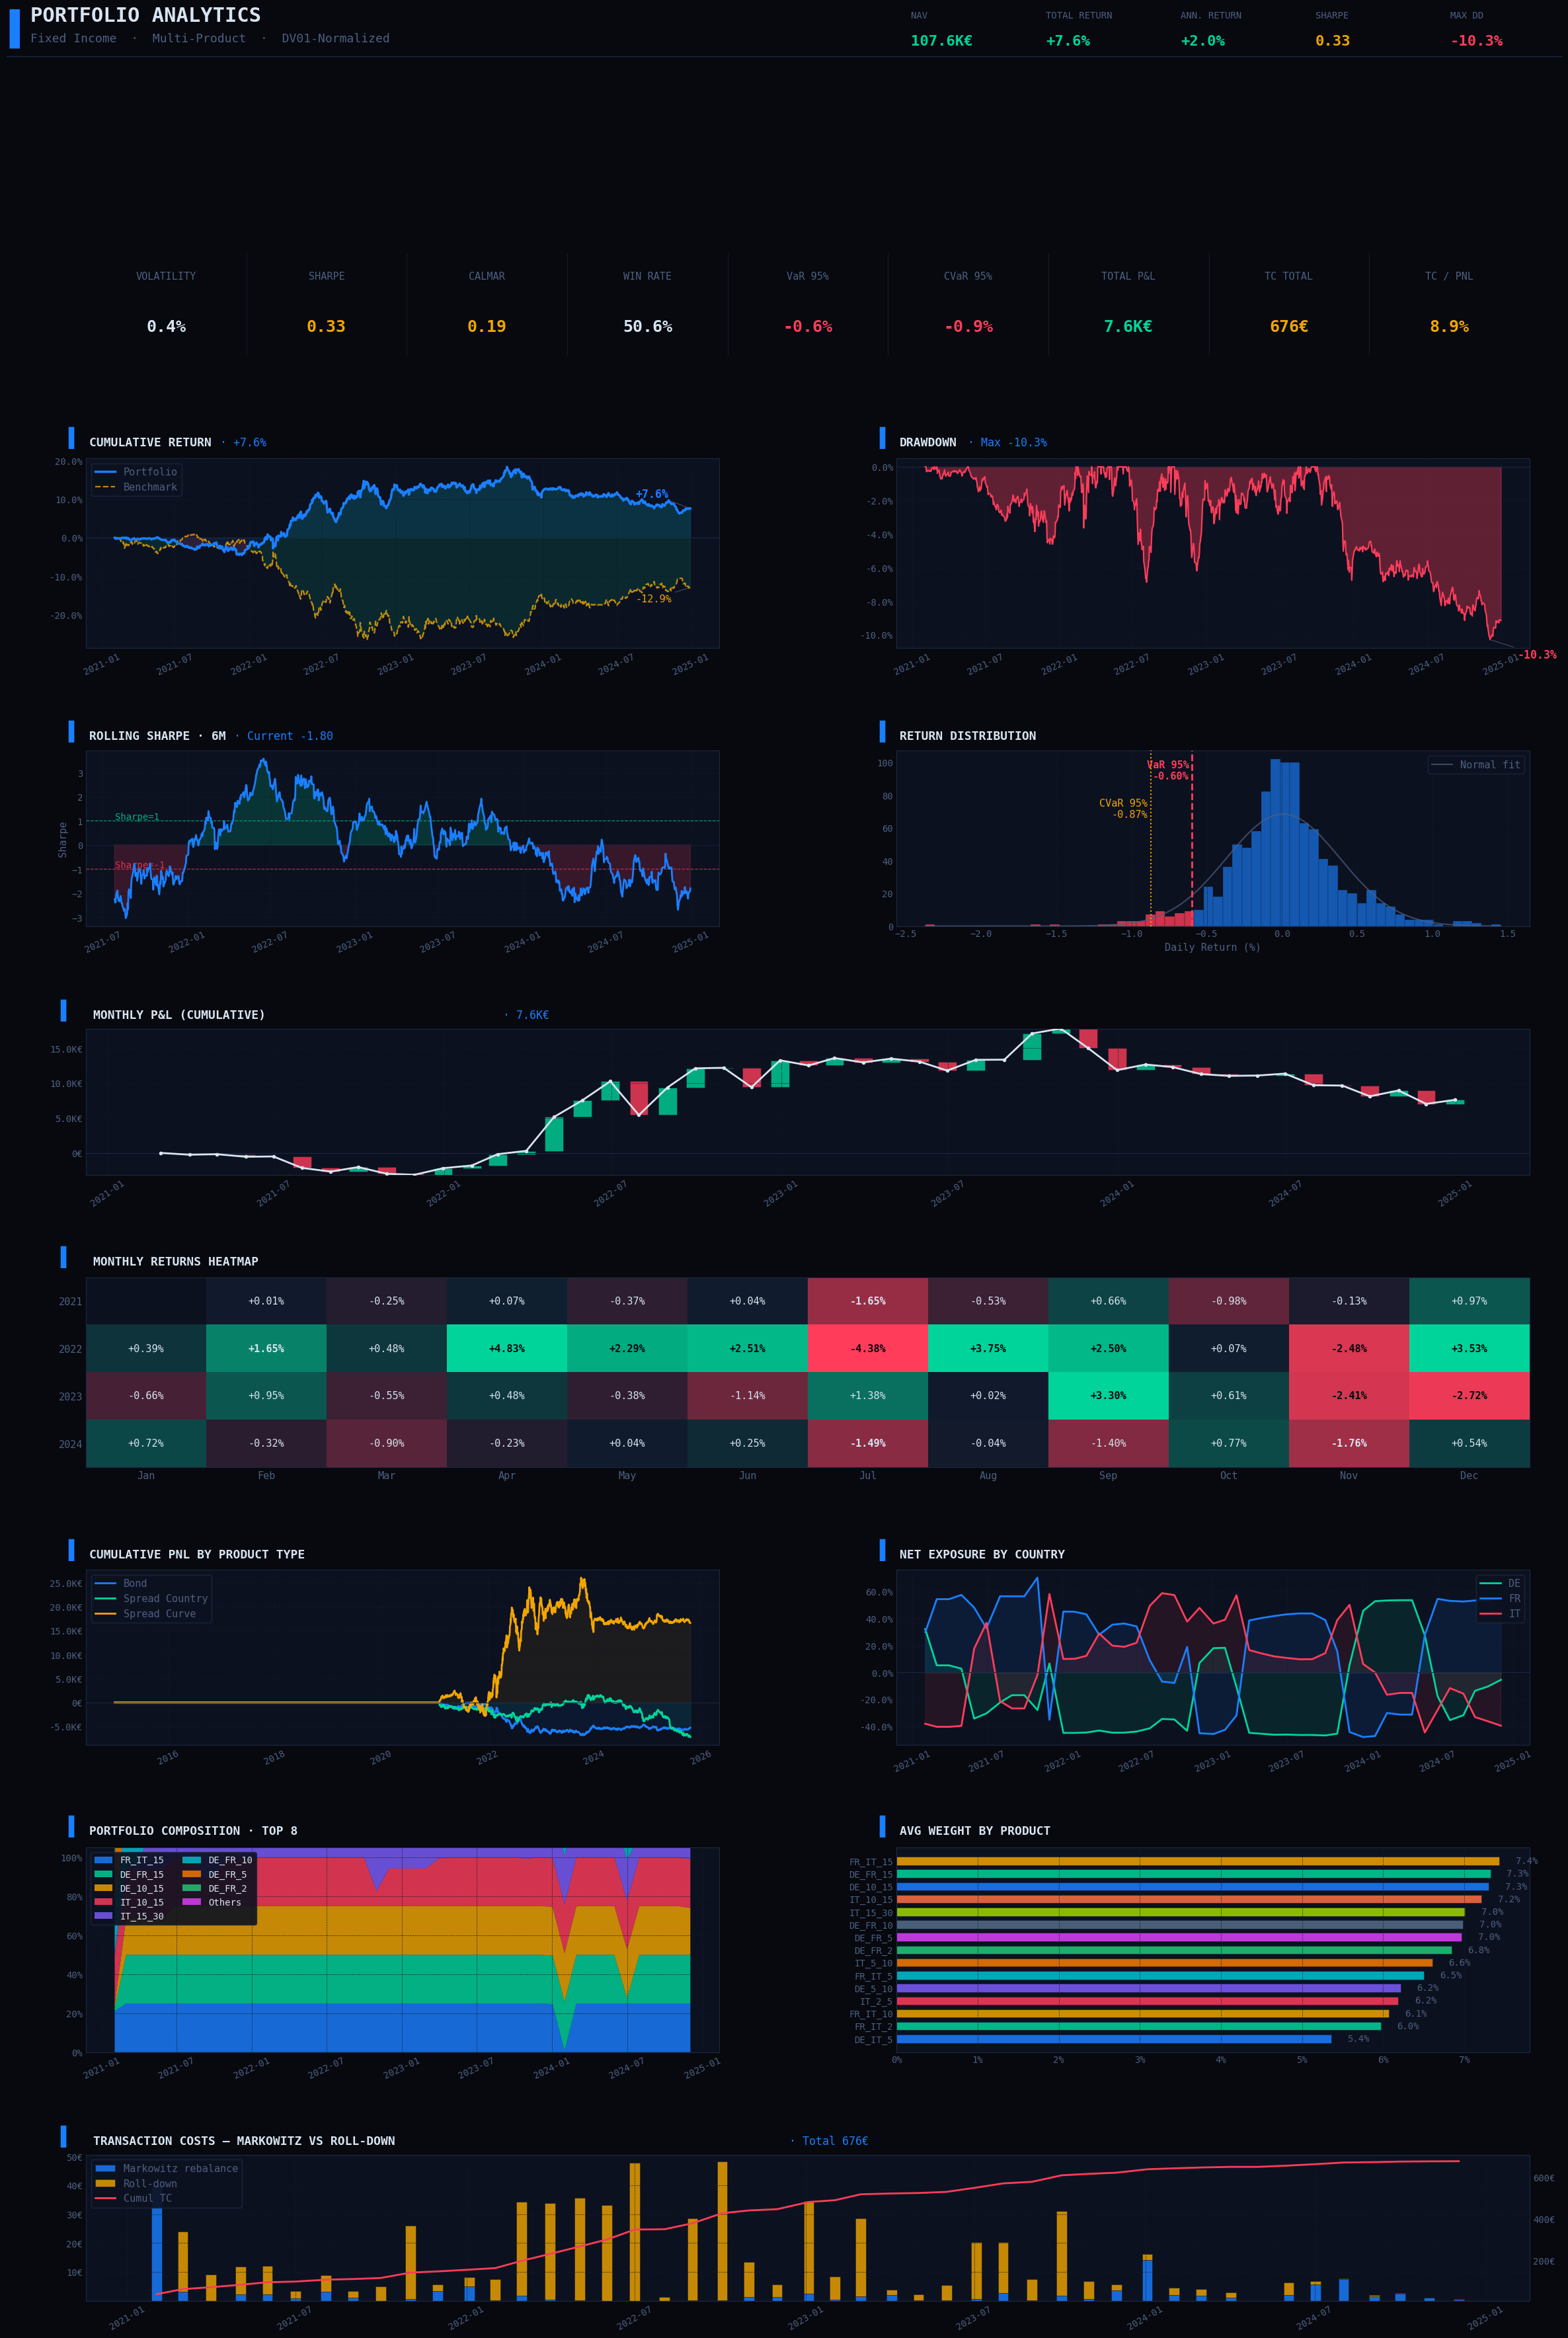

In [20]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long_filtered,
    start_date="2021-01-01",
    end_date="2025-01-01",
    rebalance_freq="ME",
    benchmark="10",
    dv01_ref=dv01_ref,
    long_only=False,
    lamb=0.01, # 0.2
    tc_gamma=17 #
    #initial_weights= df_weights["weight"]
)


tspf.generate_portfolios(carry_weight=0.75)

viz = PortfolioDashboardVisualizer(ts_portfolio=tspf)
#viz.plot_dashboard(save_path="dashboard.png", dpi=100)

fig = viz.plot_dashboard()


In [18]:
from joblib import Parallel, delayed
import itertools
import numpy as np
import pandas as pd
import warnings

param_grid = {
    "lamb"        : np.linspace(0.01, 5, 10),
    "tc_gamma"    : np.linspace(0.1, 50, 10),
    "carry_weight": np.linspace(0.5, 0.5, 1),   # 0=momentum pur, 1=carry pur
}

combinations = list(itertools.product(
    param_grid["lamb"],
    param_grid["tc_gamma"],
    param_grid["carry_weight"],
))
print(f"{len(combinations)} combinaisons à tester...")


def run_backtest(lamb, tc_gamma, carry_weight):
    try:
        tspf = TimeSeriesPortfolio(
            data                = long_filtered,
            start_date          = "2021-01-01",
            end_date            = "2025-06-10",
            rebalance_freq      = "ME",
            long_only           = False,
            lamb                = lamb,
            tc_gamma            = tc_gamma,
            dv01_ref            = dv01_ref,
                )
        tspf.generate_portfolios(carry_weight = carry_weight)

        m        = tspf.metrics
        pnl_brut = m["portfolio_pnl"].sum() + m["transaction_costs"].sum()

        return {
            "lamb"        : lamb,
            "tc_gamma"    : tc_gamma,
            "carry_weight": carry_weight,
            "sharpe"      : m["sharpe"],
            "ann_ret"     : m["mean_return"] * 252,
            "ann_vol"     : m["volatility"]  * np.sqrt(252),
            "max_dd"      : m["max_drawdown"],
            "tc_ratio"    : float(m["transaction_costs"].sum() / max(abs(pnl_brut), 1)),
        }

    except Exception as e:
        return {
            "lamb": lamb, "tc_gamma": tc_gamma, "carry_weight": carry_weight,
            "sharpe": np.nan, "ann_ret": np.nan, "ann_vol": np.nan,
            "max_dd": np.nan, "tc_ratio": np.nan, "error": str(e),
        }


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    results = Parallel(n_jobs=-1, verbose=5)(
        delayed(run_backtest)(lamb, tc_gamma, carry_weight)
        for lamb, tc_gamma, carry_weight in combinations
    )

df = pd.DataFrame(results)

df["score"] = (
      df["sharpe"]
)

df = df.sort_values("score", ascending=False)
print(df[[
    "lamb", "tc_gamma", "carry_weight",
    "score", "sharpe", "ann_ret", "ann_vol", "max_dd", "tc_ratio"
]].head(20).to_string(index=False))

100 combinaisons à tester...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.9min finished


    lamb  tc_gamma  carry_weight    score   sharpe  ann_ret  ann_vol    max_dd  tc_ratio
0.564444 16.733333           0.5 0.577319 0.577319 0.007691 0.013321 -0.019650  0.132663
0.010000 38.911111           0.5 0.557182 0.557182 0.015565 0.027935 -0.036886  0.070246
0.564444 22.277778           0.5 0.557054 0.557054 0.007614 0.013668 -0.019379  0.131416
0.564444 27.822222           0.5 0.551299 0.551299 0.007733 0.014028 -0.019225  0.126843
0.564444 33.366667           0.5 0.549840 0.549840 0.007937 0.014436 -0.019326  0.124219
0.564444 11.188889           0.5 0.541820 0.541820 0.007174 0.013241 -0.019316  0.144715
0.564444 38.911111           0.5 0.533078 0.533078 0.007872 0.014768 -0.019042  0.126271
0.564444 44.455556           0.5 0.519685 0.519685 0.007840 0.015086 -0.018754  0.125987
0.564444 50.000000           0.5 0.510099 0.510099 0.007837 0.015363 -0.018424  0.124820
0.010000 44.455556           0.5 0.501617 0.501617 0.014011 0.027931 -0.044126  0.077460
1.118889 50.000000   

In [19]:
df.sort_values("ann_ret", ascending=False).head(50)

,lamb,tc_gamma,carry_weight,sharpe,ann_ret,ann_vol,max_dd,tc_ratio,error,score
1,0.010000,5.644444,0.5,0.469240,0.047832,0.101935,-0.138683,0.100530,NaN,0.469240
2,0.010000,11.188889,0.5,0.400943,0.027481,0.068541,-0.099189,0.073111,NaN,0.400943
3,0.010000,16.733333,0.5,0.386195,0.021224,0.054956,-0.096239,0.071201,NaN,0.386195
7,0.010000,38.911111,0.5,0.557182,0.015565,0.027935,-0.036886,0.070246,NaN,0.557182
5,0.010000,27.822222,0.5,0.468849,0.015187,0.032392,-0.040505,0.077262,NaN,0.468849
6,0.010000,33.366667,0.5,0.482062,0.014701,0.030496,-0.035948,0.077216,NaN,0.482062
8,0.010000,44.455556,0.5,0.501617,0.014011,0.027931,-0.044126,0.077460,NaN,0.501617
9,0.010000,50.000000,0.5,0.422409,0.010645,0.025200,-0.041618,0.098071,NaN,0.422409
4,0.010000,22.277778,0.5,0.248774,0.010476,0.042111,-0.083554,0.121511,NaN,0.248774
16,0.564444,33.366667,0.5,0.549840,0.007937,0.014436,-0.019326,0.124219,NaN,0.549840


In [ ]:
df.sort_values("sharpe", ascending=False).head(50)

,lamb,tc_gamma,carry_weight,sharpe,ann_ret,ann_vol,max_dd,tc_ratio,error,score
118,0.222778,15025.0,0.625,1.034321,0.019528,0.018880,-0.022395,0.008291,NaN,1.034321
143,0.278222,15025.0,0.625,1.027923,0.017401,0.016928,-0.021082,0.008952,NaN,1.027923
168,0.333667,15025.0,0.625,1.006316,0.015814,0.015715,-0.019998,0.009893,NaN,1.006316
119,0.222778,15025.0,0.750,1.003893,0.019497,0.019422,-0.023004,0.008294,NaN,1.003893
93,0.167333,15025.0,0.625,0.999910,0.021940,0.021942,-0.025594,0.007605,NaN,0.999910
144,0.278222,15025.0,0.750,0.996058,0.017228,0.017296,-0.021399,0.009123,NaN,0.996058
117,0.222778,15025.0,0.500,0.995682,0.017403,0.017478,-0.021487,0.009075,NaN,0.995682
142,0.278222,15025.0,0.500,0.984301,0.015741,0.015992,-0.020534,0.009768,NaN,0.984301
198,0.389111,20000.0,0.625,0.983621,0.014730,0.014975,-0.020054,0.010287,NaN,0.983621
173,0.333667,20000.0,0.625,0.981188,0.015612,0.015911,-0.020584,0.009872,NaN,0.981188
